In [2]:
import numpy as np
import  pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns
from pyexpat import features

from scipy.stats import pearsonr, alpha

In [3]:
df=pd.read_csv('heart.csv')

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [9]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [10]:
df['Sex']=df['Sex'].map({
    'M':0,
    'F':1,
},)

In [12]:
df.rename(columns={
    "Sex":"Is_Female"
},inplace=True)

In [13]:
df.isnull().sum()

Age               0
Is_Female         0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

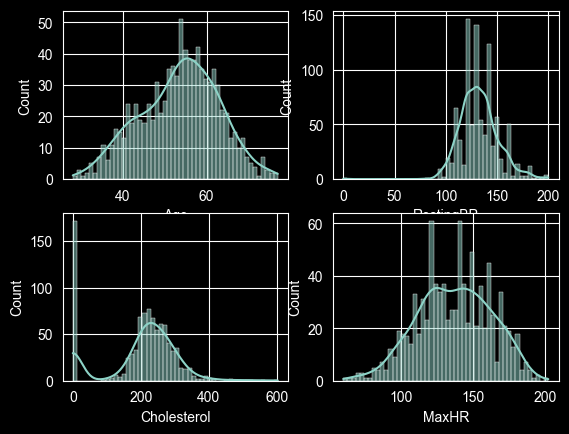

In [15]:
def ploting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True,bins=50)
ploting("Age",1)
ploting("RestingBP",2)
ploting("Cholesterol",3)
ploting("MaxHR",4)

In [ ]:
df['Cholesterol'].value_counts()

In [18]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [19]:
ch_mean

np.float64(244.6353887399464)

In [20]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)

In [21]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean).round(2)

In [22]:
res_bp_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
res_bp_mean

np.float64(132.54089422028352)

In [24]:
df.head()

,Age,Is_Female,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,1,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,0,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,1,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,0,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [25]:
df['RestingBP']=df['RestingBP'].replace(0,res_bp_mean)
df['RestingBP']=df['RestingBP'].round()

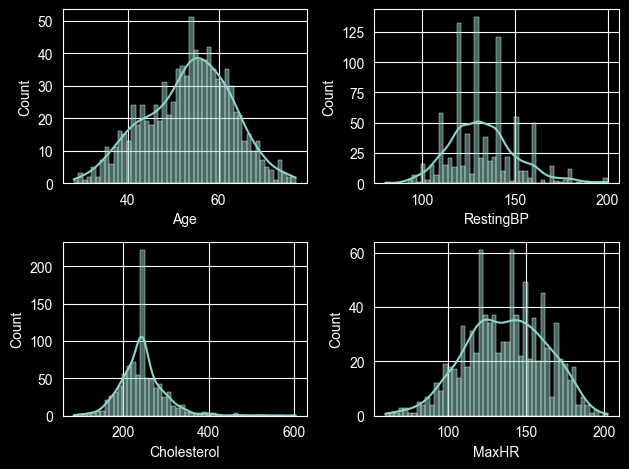

In [27]:
def ploting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True,bins=50)
ploting("Age",1)
ploting("RestingBP",2)
ploting("Cholesterol",3)
ploting("MaxHR",4)
plt.tight_layout()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import sheryanalysis as sh

In [36]:
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Is_Female', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Is_Female', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


F:\MACHINE LEARNING\.venv\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample)
F:\MACHINE LEARNING\.venv\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample)
F:\MACHINE LEARNING\.venv\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample)
F:\MACHINE LEARNING\.venv\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could not infer format, so each element will be parsed individually, fal

{'shape': (918, 12),
 'columns': ['Age',
  'Is_Female',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Is_Female': dtype('int64'),
  'ChestPainType': <StringDtype(storage='python', na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(storage='python', na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(storage='python', na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(storage='python', na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Is_Female': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types':

<Axes: xlabel='Is_Female', ylabel='count'>

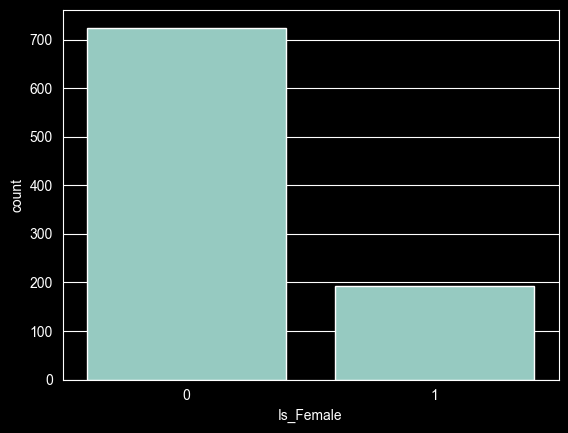

In [39]:
sns.countplot(x=df['Is_Female'])

<Axes: xlabel='ChestPainType', ylabel='count'>

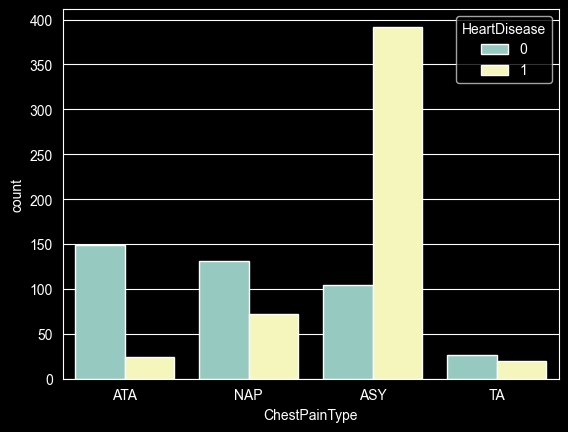

In [40]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='Is_Female', ylabel='count'>

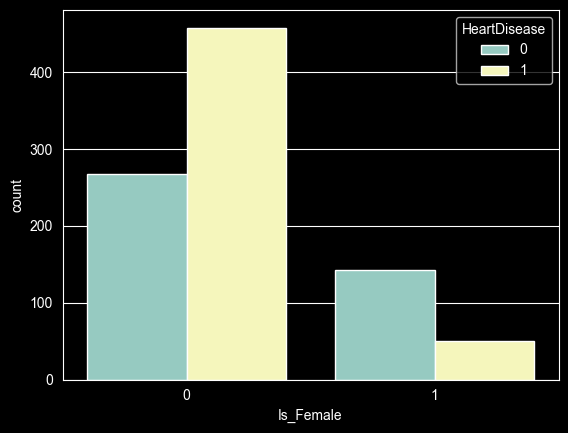

In [41]:
sns.countplot(x=df['Is_Female'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

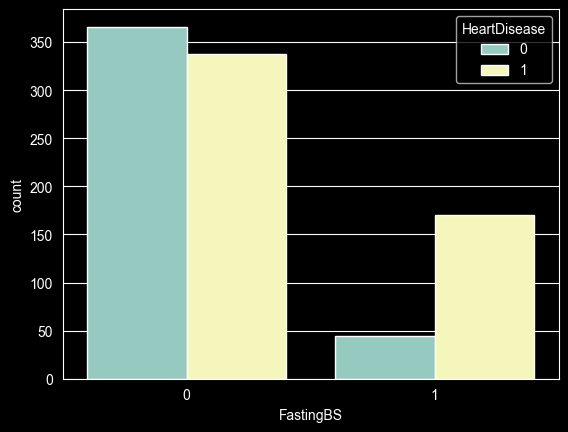

In [45]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

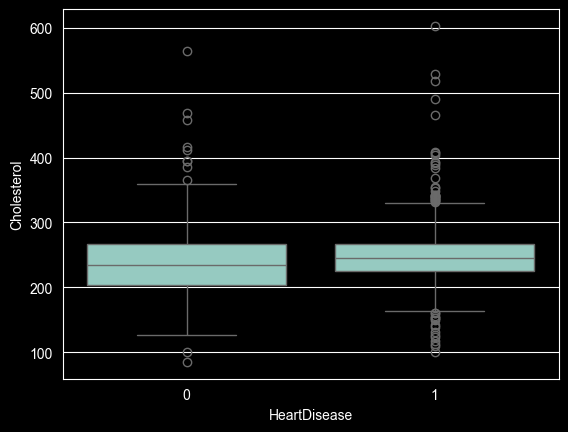

In [46]:
sns.boxplot(y='Cholesterol',x='HeartDisease',data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

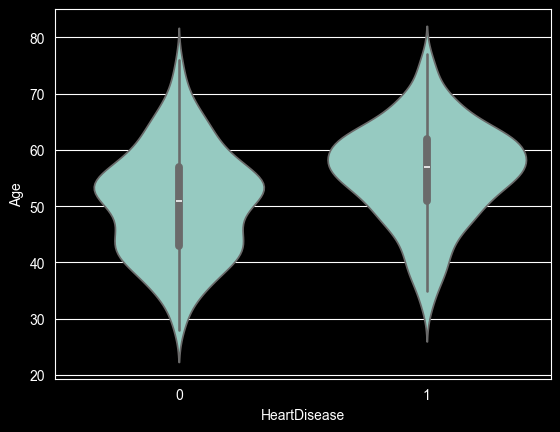

In [47]:
sns.violinplot(x='HeartDisease',y='Age',data=df)

<Axes: >

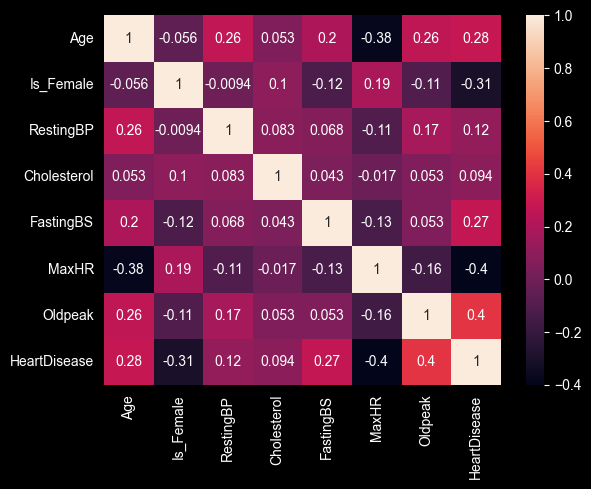

In [48]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Perprocessing and Cleaning

In [49]:
df_encode=pd.get_dummies(df,drop_first=True)

In [51]:
df_encode.astype(int)

,Age,Is_Female,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0,1,0,0,1,0,0,0,1
1,49,1,160,180,0,156,1,1,0,1,0,1,0,0,1,0
2,37,0,130,283,0,98,0,0,1,0,0,0,1,0,0,1
3,48,1,138,214,0,108,1,1,0,0,0,1,0,1,1,0
4,54,0,150,195,0,122,0,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,1,1,0,0,1,1,0,0,1,0
914,68,0,144,193,1,141,3,1,0,0,0,1,0,0,1,0
915,57,0,130,131,0,115,1,1,0,0,0,1,0,1,1,0
916,57,1,130,236,0,174,0,1,1,0,0,0,0,0,1,0


In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
num_col=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

In [54]:
scaler=StandardScaler()
df_encode[num_col]=scaler.fit_transform(df_encode[num_col])

In [55]:
df_encode.head()

,Age,Is_Female,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414825,0.832513,0,1.382928,-0.832432,0,True,False,False,True,False,False,False,True
1,-0.478484,1,1.527163,-1.212938,0,0.754157,0.105664,1,False,True,False,True,False,False,True,False
2,-1.751359,0,-0.141345,0.719919,0,-1.525138,-0.832432,0,True,False,False,False,True,False,False,True
3,-0.584556,1,0.303591,-0.574908,0,-1.132156,0.574711,1,False,False,False,True,False,True,True,False
4,0.051881,0,0.970994,-0.931454,0,-0.581981,-0.832432,0,False,True,False,True,False,False,False,True


In [56]:
df_encode.astype(int)

,Age,Is_Female,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1
1,0,1,1,-1,0,0,0,1,0,1,0,1,0,0,1,0
2,-1,0,0,0,0,-1,0,0,1,0,0,0,1,0,0,1
3,0,1,0,0,0,-1,0,1,0,0,0,1,0,1,1,0
4,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,0,0,-1,0,0,0,0,1,0,0,1,1,0,0,1,0
914,1,0,0,0,1,0,2,1,0,0,0,1,0,0,1,0
915,0,0,0,-2,0,0,0,1,0,0,0,1,0,1,1,0
916,0,1,0,0,0,1,0,1,1,0,0,0,0,0,1,0


In [57]:
df_encode.head()

,Age,Is_Female,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0,0.414825,0.832513,0,1.382928,-0.832432,0,True,False,False,True,False,False,False,True
1,-0.478484,1,1.527163,-1.212938,0,0.754157,0.105664,1,False,True,False,True,False,False,True,False
2,-1.751359,0,-0.141345,0.719919,0,-1.525138,-0.832432,0,True,False,False,False,True,False,False,True
3,-0.584556,1,0.303591,-0.574908,0,-1.132156,0.574711,1,False,False,False,True,False,True,True,False
4,0.051881,0,0.970994,-0.931454,0,-0.581981,-0.832432,0,False,True,False,True,False,False,False,True
